# ECG Classification — Phase 1: Combined Data Preparation

This notebook merges the original pipeline (raw signals + NeuroKit2 features) with Anora's spectrogram approach (3-channel STFT + CWT + Recurrence Plot, 224×224). All outputs are saved to `../../dataset/input/ECG_Hierarchical/` for use in Phase 2.

**Outputs**
| File | Used by | Notes |
|------|---------|-------|
| `X_train_sig.npy` | Stage 1 TCN | (N, 4500) raw windowed signals |
| `X_test_sig.npy` | Stage 1 TCN | (N, 4500) |
| `X_train_feat.npy` | Stage 1 fusion | (N, n_feat) NeuroKit2 features |
| `X_test_feat.npy` | Stage 1 fusion | (N, n_feat) |
| `X_train_spec.dat` | Stage 2 EfficientNet | (N, 3, 224, 224) memory-mapped |
| `X_test_spec.dat` | Stage 2 EfficientNet | (N, 3, 224, 224) memory-mapped |
| `y_train_4class.npy` | Labels | 0=N 1=A 2=O 3=~ |
| `y_train_binary.npy` | Stage 1 | 0=Normal 1=NonNormal |
| `y_train_3class.npy` | Stage 2 | 0=A 1=O 2=~ (non-Normal only) |
| `nonnormal_mask.npy` | Indexing | bool mask into train arrays |
| `y_test.npy` | Evaluation | 4-class test labels |
| `scaler.pkl` | Feature scaling | Fitted StandardScaler |
| `feat_cols.pkl` | Feature names | List of NeuroKit2 column names |

## 1 · Imports and output directory

In [1]:
import os
import numpy as np
import pandas as pd
import pywt
import pickle
import scipy.signal
from tqdm.auto import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.transform import resize

os.makedirs("../../dataset/input/ECG_Hierarchical", exist_ok=True)
print("Output directory: ../../dataset/input/ECG_Hierarchical/")

c:\Users\CHERISH\DEV\CollegeProjects\Atrial-Fibrillation-Detection\ecg_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output directory: ../../dataset/input/ECG_Hierarchical/


## 2 · Global constants

In [2]:
FS          = 300         # sampling frequency (Hz)
WINDOW_SIZE = 4500        # 15 seconds
STEP_TRAIN  = 2250        # 50 % overlap for train windows
STEP_TEST   = 4500        # non-overlapping for test windows
IMG_SIZE    = 224         # spectrogram spatial size (Anora's EfficientNet-B2 input)
RANDOM_STATE = 42

LABEL_MAP   = {"N": 0, "A": 1, "O": 2, "~": 3}

# Augmentation targets (train only, non-Normal classes only)
# multiplier = 2  →  double each minority class
AUG_TARGETS = {1: 2, 2: 2, 3: 2}   # label_id → multiplier


## 3 · Load raw data

Expected in `../../dataset/input/ECG_Processed_Dataset/`:
- `ecg_meta.csv` — columns `record_id`, `label` (N/A/O/~)
- `ecg_signals.npy` — (n_records,) array of variable-length 1-D signals
- `ecg_features.csv` — NeuroKit2 features, one row per record

In [3]:
DATA_DIR = "../../dataset/input/ECG_Processed_Dataset"

meta    = pd.read_csv(f"{DATA_DIR}/ecg_meta.csv")
signals = np.load(f"{DATA_DIR}/ecg_signals.npy", allow_pickle=True)

print("Records :", len(meta))
print("Signal array shape:", signals.shape)
print("Label distribution:")
print(meta["label"].value_counts())

Records : 8528
Signal array shape: (8528,)
Label distribution:
label
N    5050
O    2456
A     738
~     284
Name: count, dtype: int64


## 4 · Record-level train / test split

Splitting *records* (not windows) prevents data leakage — windows from the same recording would be nearly identical and inflate test metrics if mixed across the split.

In [4]:
record_ids    = meta["record_id"].values
record_labels = meta["label"].values

train_ids, test_ids = train_test_split(
    record_ids,
    test_size=0.2,
    stratify=record_labels,
    random_state=RANDOM_STATE
)

train_mask = meta["record_id"].isin(train_ids).values
test_mask  = meta["record_id"].isin(test_ids).values

train_meta = meta[train_mask].reset_index(drop=True)
test_meta  = meta[test_mask].reset_index(drop=True)
train_sigs = signals[train_mask]
test_sigs  = signals[test_mask]

print(f"Train records: {len(train_meta)}  |  Test records: {len(test_meta)}")
print("Train label distribution:")
print(train_meta["label"].value_counts())

Train records: 6822  |  Test records: 1706
Train label distribution:
label
N    4040
O    1965
A     590
~     227
Name: count, dtype: int64


## 5 · Bandpass filter and Z-score normalisation

**Bandpass 0.5–45 Hz**: removes DC drift and high-frequency noise while preserving ECG morphology.  
**Z-score**: zero-mean, unit-variance per window — makes the model insensitive to recording amplitude.

In [5]:
def bandpass_filter(signal, lowcut=0.5, highcut=45.0, fs=300.0, order=2):
    nyq  = 0.5 * fs
    b, a = scipy.signal.butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return scipy.signal.filtfilt(b, a, np.array(signal, dtype=np.float64))

def zscore_normalize(signal):
    mu, std = signal.mean(), signal.std()
    return (signal - mu) / (std + 1e-8)

def preprocess_signal(signal):
    return zscore_normalize(bandpass_filter(signal)).astype(np.float32)

## 6 · Sliding-window extraction

In [6]:
def extract_windows(signal, record_id, label_id, window_size, step):
    windows, labels, rids = [], [], []
    n = len(signal)
    start = 0
    while start + window_size <= n:
        windows.append(signal[start : start + window_size])
        labels.append(label_id)
        rids.append(record_id)
        start += step
    return windows, labels, rids

def build_windows(meta_df, sigs, window_size, step):
    all_windows, all_labels, all_rids = [], [], []
    for i, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="Windowing"):
        record_id = row["record_id"]
        label_id  = LABEL_MAP[row["label"]]
        signal    = preprocess_signal(sigs[i])
        w, l, r   = extract_windows(signal, record_id, label_id, window_size, step)
        all_windows.extend(w)
        all_labels.extend(l)
        all_rids.extend(r)
    return (
        np.array(all_windows, dtype=np.float32),
        np.array(all_labels,  dtype=np.int64),
        np.array(all_rids)
    )

train_wins, train_labels, train_rids = build_windows(train_meta, train_sigs, WINDOW_SIZE, STEP_TRAIN)
test_wins,  test_labels,  test_rids  = build_windows(test_meta,  test_sigs,  WINDOW_SIZE, STEP_TEST)

print(f"Train windows: {len(train_wins)}  |  Test windows: {len(test_wins)}")
for lbl, name in LABEL_MAP.items():
    tc = (train_labels == name).sum()
    ec = (test_labels  == name).sum()
    print(f"  {lbl}: train={tc}  test={ec}")

Windowing: 100%|██████████| 1706/1706 [00:01<00:00, 1100.80it/s]


Train windows: 22083  |  Test windows: 3496
  N: train=12895  test=2042
  A: train=1856  test=307
  O: train=6900  test=1067
  ~: train=432  test=80


## 7 · Augmentation — minority classes only (CutMix + Gaussian noise)

Only non-Normal classes (A, O, ~) are augmented in the training set.
**CutMix-1D**: swaps a contiguous random segment between two same-class windows.  
**Gaussian noise**: mild σ = 0.01 × signal std to prevent exact copies.

In [7]:
def cutmix_1d(sig_a, sig_b, alpha=0.3):
    lam    = np.random.beta(alpha, alpha)
    length = int(WINDOW_SIZE * lam)
    start  = np.random.randint(0, max(1, WINDOW_SIZE - length))
    out    = sig_a.copy()
    out[start : start + length] = sig_b[start : start + length]
    return out

def augment_windows(windows, labels, rids, aug_targets, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    aug_wins, aug_labs, aug_rids = [], [], []

    for label, multiplier in aug_targets.items():
        class_idx = np.where(labels == label)[0]
        n_orig    = len(class_idx)
        n_needed  = n_orig * multiplier - n_orig

        for _ in range(n_needed):
            i     = rng.choice(class_idx)
            j     = rng.choice(class_idx)
            mixed = cutmix_1d(windows[i], windows[j])
            noise = rng.normal(0, 0.01 * mixed.std(), size=mixed.shape).astype(np.float32)
            aug_wins.append(mixed + noise)
            aug_labs.append(label)
            aug_rids.append(rids[i])

    if not aug_wins:
        return windows, labels, rids

    aug_wins = np.array(aug_wins, dtype=np.float32)
    aug_labs = np.array(aug_labs, dtype=np.int64)
    aug_rids = np.array(aug_rids)

    wins_out  = np.concatenate([windows, aug_wins], axis=0)
    labs_out  = np.concatenate([labels,  aug_labs], axis=0)
    rids_out  = np.concatenate([rids,    aug_rids], axis=0)

    perm = rng.permutation(len(wins_out))
    return wins_out[perm], labs_out[perm], rids_out[perm]

train_wins, train_labels, train_rids = augment_windows(
    train_wins, train_labels, train_rids, AUG_TARGETS
)

print(f"After augmentation — train windows: {len(train_wins)}")
for lbl, name in LABEL_MAP.items():
    print(f"  {lbl}: {(train_labels == name).sum()}")

After augmentation — train windows: 31271
  N: 12895
  A: 3712
  O: 13800
  ~: 864


## 8 · Save raw windowed signals (Stage 1 input)

In [8]:
np.save("../../dataset/input/ECG_Hierarchical/X_train_sig.npy", train_wins)
np.save("../../dataset/input/ECG_Hierarchical/X_test_sig.npy",  test_wins)

print("X_train_sig:", train_wins.shape)
print("X_test_sig :", test_wins.shape)

X_train_sig: (31271, 4500)
X_test_sig : (3496, 4500)


## 9 · Build label arrays

In [9]:
y_train_4class = train_labels.astype(np.int64)
y_test         = test_labels.astype(np.int64)
y_train_binary = (y_train_4class != 0).astype(np.int64)
nonnormal_mask = (y_train_4class != 0)
y_train_3class = (y_train_4class[nonnormal_mask] - 1).astype(np.int64)

np.save("../../dataset/input/ECG_Hierarchical/y_train_4class.npy", y_train_4class)
np.save("../../dataset/input/ECG_Hierarchical/y_train_binary.npy", y_train_binary)
np.save("../../dataset/input/ECG_Hierarchical/y_train_3class.npy", y_train_3class)
np.save("../../dataset/input/ECG_Hierarchical/nonnormal_mask.npy", nonnormal_mask)
np.save("../../dataset/input/ECG_Hierarchical/y_test.npy",         y_test)

print("y_train_4class :", y_train_4class.shape, dict(Counter(y_train_4class.tolist())))
print("y_train_binary :", y_train_binary.shape, dict(Counter(y_train_binary.tolist())))
print("y_train_3class :", y_train_3class.shape, dict(Counter(y_train_3class.tolist())))
print("y_test         :", y_test.shape,          dict(Counter(y_test.tolist())))

y_train_4class : (31271,) {1: 3712, 0: 12895, 2: 13800, 3: 864}
y_train_binary : (31271,) {1: 18376, 0: 12895}
y_train_3class : (18376,) {0: 3712, 1: 13800, 2: 864}
y_test         : (3496,) {0: 2042, 1: 307, 2: 1067, 3: 80}


## 10 · NeuroKit2 feature alignment (Stage 1 fusion)

Record-level features from `ecg_features.csv` are broadcast to every window from the same record. `StandardScaler` is fitted on **train windows only** to prevent test-set leakage.

In [10]:
features_df = pd.read_csv(f"{DATA_DIR}/ecg_features.csv")
feat_cols   = [c for c in features_df.columns if c not in ["record_id", "label"]]
print(f"NeuroKit2 feature columns ({len(feat_cols)}):", feat_cols[:10], "...")

NeuroKit2 feature columns (39): ['rr_mean', 'rr_std', 'rr_min', 'rr_max', 'rr_range', 'rr_cv', 'rr_median', 'rr_iqr', 'rr_skewness', 'rr_kurtosis'] ...


In [11]:
def align_features(windows_rids, features_df, feat_cols):
    rid_df = pd.DataFrame({"record_id": windows_rids})
    merged = rid_df.merge(
        features_df[["record_id"] + feat_cols],
        on="record_id", how="left"
    )
    return merged[feat_cols].fillna(0).values.astype(np.float32)

X_train_feat_raw = align_features(train_rids, features_df, feat_cols)
X_test_feat_raw  = align_features(test_rids,  features_df, feat_cols)

scaler        = StandardScaler()
X_train_feat  = scaler.fit_transform(X_train_feat_raw).astype(np.float32)
X_test_feat   = scaler.transform(X_test_feat_raw).astype(np.float32)

np.save("../../dataset/input/ECG_Hierarchical/X_train_feat.npy", X_train_feat)
np.save("../../dataset/input/ECG_Hierarchical/X_test_feat.npy",  X_test_feat)
with open("../../dataset/input/ECG_Hierarchical/scaler.pkl",   "wb") as f: pickle.dump(scaler, f)
with open("../../dataset/input/ECG_Hierarchical/feat_cols.pkl","wb") as f: pickle.dump(feat_cols, f)

print("X_train_feat:", X_train_feat.shape, " mean:", X_train_feat.mean().round(4))
print("X_test_feat :", X_test_feat.shape)
print("Scaler and feat_cols saved.")

X_train_feat: (31271, 39)  mean: -0.0
X_test_feat : (3496, 39)
Scaler and feat_cols saved.


## 11 · 3-Channel Spectrogram Generation (Stage 2 input)

Anora's approach — three complementary views of each window:

| Channel | Transform | Captures |
|---------|-----------|----------|
| 0 | STFT log-magnitude | Frequency–time distribution |
| 1 | CWT (Morlet) | Multi-scale time-frequency content |
| 2 | Recurrence Plot | Non-linear phase-space dynamics |

All channels are resized to `(IMG_SIZE, IMG_SIZE)` = `(224, 224)` for EfficientNet-B2 input.

Only **non-Normal** windows are used for Stage 2 (3-class classification: A vs O vs ~). Labels are remapped: A→0, O→1, ~→2.

In [12]:
def compute_stft_channel(signal, img_size=IMG_SIZE):
    frame_size = 256
    hop_size   = 64
    n_frames   = (len(signal) - frame_size) // hop_size + 1
    window_fn  = np.hanning(frame_size)
    stft       = np.zeros((frame_size // 2, n_frames), dtype=np.float32)
    for i in range(n_frames):
        start        = i * hop_size
        frame        = signal[start : start + frame_size] * window_fn
        spectrum     = np.abs(np.fft.fft(frame)[: frame_size // 2])
        stft[:, i]   = spectrum
    log_stft = np.log1p(stft)
    return resize(log_stft, (img_size, img_size), anti_aliasing=True).astype(np.float32)

def compute_cwt_channel(signal, img_size=IMG_SIZE):
    scales    = np.arange(1, 129)
    coef, _   = pywt.cwt(signal, scales, "morl")
    magnitude = np.abs(coef).astype(np.float32)
    return resize(magnitude, (img_size, img_size), anti_aliasing=True).astype(np.float32)

def compute_recurrence_channel(signal, img_size=IMG_SIZE, emb_dim=3, tau=1):
    n        = len(signal)
    max_i    = n - (emb_dim - 1) * tau
    embedded = np.stack([signal[i * tau : i * tau + max_i] for i in range(emb_dim)], axis=1)
    max_pts  = 1000
    if len(embedded) > max_pts:
        idx      = np.linspace(0, len(embedded) - 1, max_pts, dtype=int)
        embedded = embedded[idx]
    diff      = embedded[:, None, :] - embedded[None, :, :]
    dist      = np.sqrt((diff ** 2).sum(axis=-1)).astype(np.float32)
    threshold = np.percentile(dist, 10)
    rp        = (dist <= threshold).astype(np.float32)
    return resize(rp, (img_size, img_size), anti_aliasing=True).astype(np.float32)

def normalise_channel(ch):
    mn, mx = ch.min(), ch.max()
    if mx - mn < 1e-8:
        return np.zeros_like(ch)
    return (ch - mn) / (mx - mn)

def build_spectrogram(signal):
    stft_ch = normalise_channel(compute_stft_channel(signal))
    cwt_ch  = normalise_channel(compute_cwt_channel(signal))
    rp_ch   = normalise_channel(compute_recurrence_channel(signal))
    return np.stack([stft_ch, cwt_ch, rp_ch], axis=0)   # (3, 224, 224)


### 11a · Select non-Normal windows for Stage 2

In [13]:
# Stage 2 uses only non-Normal windows; labels remapped A→0, O→1, ~→2
s2_label_remap = {1: 0, 2: 1, 3: 2}

nn_train_mask  = train_labels != 0
nn_test_mask   = test_labels  != 0

s2_train_wins   = train_wins[nn_train_mask]
s2_train_labels = np.array([s2_label_remap[l] for l in train_labels[nn_train_mask]], dtype=np.int64)
s2_train_rids   = train_rids[nn_train_mask]

s2_test_wins    = test_wins[nn_test_mask]
s2_test_labels  = np.array([s2_label_remap[l] for l in test_labels[nn_test_mask]], dtype=np.int64)
s2_test_rids    = test_rids[nn_test_mask]

print(f"Stage 2 train windows: {len(s2_train_wins)}")
print("  Class distribution:", dict(Counter(s2_train_labels.tolist())), "(0=A 1=O 2=~)")
print(f"Stage 2 test  windows: {len(s2_test_wins)}")
print("  Class distribution:", dict(Counter(s2_test_labels.tolist())))

Stage 2 train windows: 18376
  Class distribution: {0: 3712, 1: 13800, 2: 864} (0=A 1=O 2=~)
Stage 2 test  windows: 1454
  Class distribution: {0: 307, 1: 1067, 2: 80}


### 11b · Generate and memory-map train spectrograms

Flushed to disk every 200 windows so a crash doesn't lose progress.

In [14]:
n_train_s2     = len(s2_train_wins)
train_spec_path = "../../dataset/input/ECG_Hierarchical/X_train_spec.dat"

train_spec_mm = np.memmap(train_spec_path, dtype="float32", mode="w+",
                           shape=(n_train_s2, 3, IMG_SIZE, IMG_SIZE))

FLUSH_EVERY = 200
for i in tqdm(range(n_train_s2), desc="Train spectrograms"):
    train_spec_mm[i] = build_spectrogram(s2_train_wins[i])
    if (i + 1) % FLUSH_EVERY == 0:
        train_spec_mm.flush()
train_spec_mm.flush()

np.save("../../dataset/input/ECG_Hierarchical/y_train_3class_spec.npy", s2_train_labels)
np.save("../../dataset/input/ECG_Hierarchical/train_rids_spec.npy",     s2_train_rids)
print("Train spectrograms saved:", train_spec_mm.shape)

Train spectrograms: 100%|██████████| 18376/18376 [1:50:52<00:00,  2.76it/s]


Train spectrograms saved: (18376, 3, 224, 224)


### 11c · Generate and memory-map test spectrograms

In [15]:
n_test_s2      = len(s2_test_wins)
test_spec_path  = "../../dataset/input/ECG_Hierarchical/X_test_spec.dat"

test_spec_mm = np.memmap(test_spec_path, dtype="float32", mode="w+",
                          shape=(n_test_s2, 3, IMG_SIZE, IMG_SIZE))

for i in tqdm(range(n_test_s2), desc="Test spectrograms"):
    test_spec_mm[i] = build_spectrogram(s2_test_wins[i])
    if (i + 1) % FLUSH_EVERY == 0:
        test_spec_mm.flush()
test_spec_mm.flush()

np.save("../../dataset/input/ECG_Hierarchical/y_test_3class_spec.npy", s2_test_labels)
np.save("../../dataset/input/ECG_Hierarchical/test_rids_spec.npy",     s2_test_rids)
print("Test spectrograms saved:", test_spec_mm.shape)

Test spectrograms: 100%|██████████| 1454/1454 [09:46<00:00,  2.48it/s]

Test spectrograms saved: (1454, 3, 224, 224)


### 11d · Save memmap shape metadata

In [16]:
memmap_shapes = {
    "train_spec": (n_train_s2, 3, IMG_SIZE, IMG_SIZE),
    "test_spec":  (n_test_s2,  3, IMG_SIZE, IMG_SIZE),
}
with open("../../dataset/input/ECG_Hierarchical/memmap_shapes.pkl", "wb") as f:
    pickle.dump(memmap_shapes, f)
print("Memmap shapes saved:", memmap_shapes)

Memmap shapes saved: {'train_spec': (18376, 3, 224, 224), 'test_spec': (1454, 3, 224, 224)}


## 12 · Sanity check — visualise one spectrogram per Stage 2 class

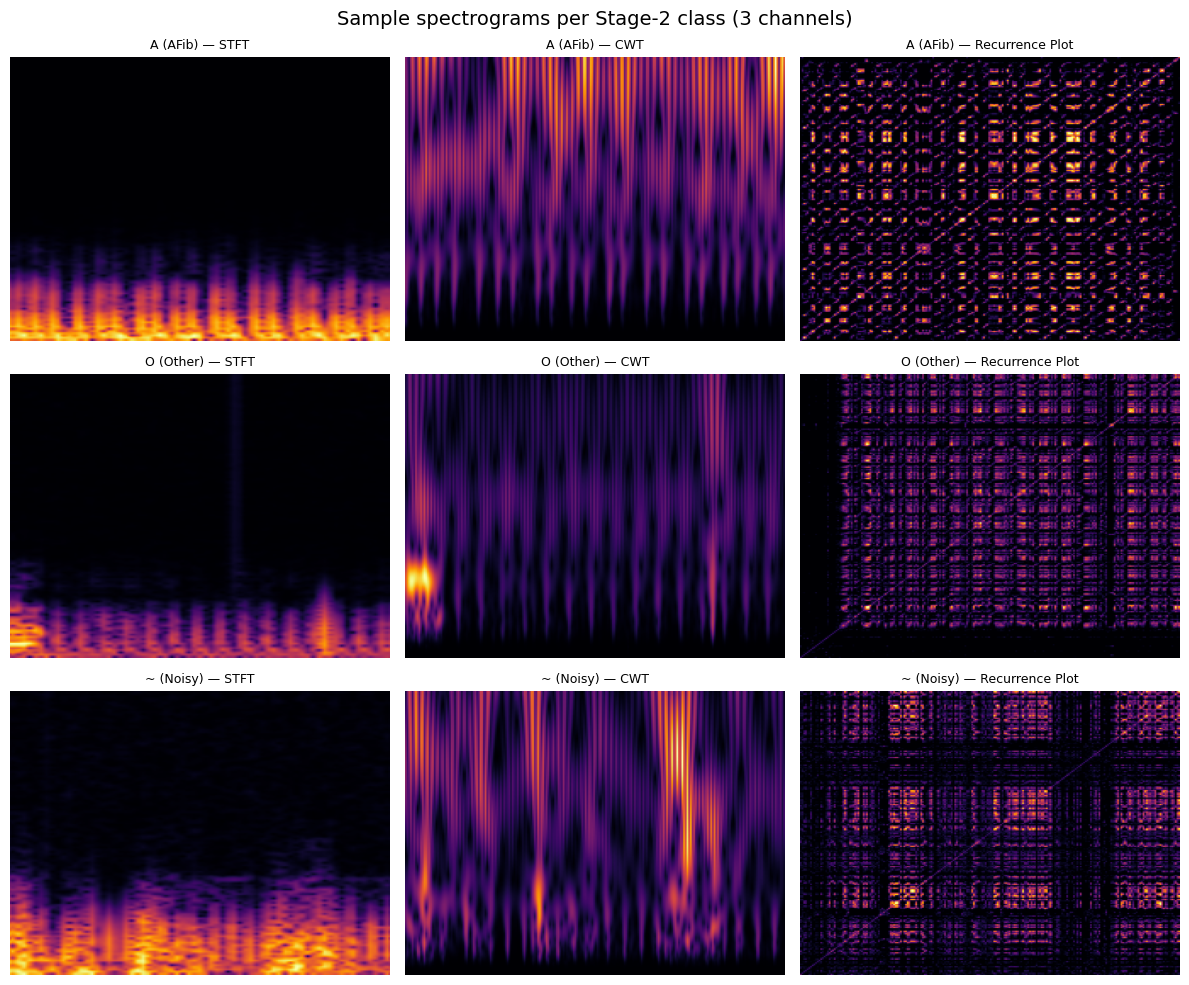

In [17]:
import matplotlib.pyplot as plt

class_names = ["A (AFib)", "O (Other)", "~ (Noisy)"]
channel_names = ["STFT", "CWT", "Recurrence Plot"]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Sample spectrograms per Stage-2 class (3 channels)", fontsize=14)

for cls_idx, cls_name in enumerate(class_names):
    idx = np.where(s2_train_labels == cls_idx)[0][0]
    spec = train_spec_mm[idx]    # (3, 224, 224)
    for ch in range(3):
        ax = axes[cls_idx][ch]
        ax.imshow(spec[ch], aspect="auto", cmap="inferno", origin="lower")
        ax.set_title(f"{cls_name} — {channel_names[ch]}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.savefig("../../dataset/input/ECG_Hierarchical/sample_spectrograms.png", dpi=100)
plt.show()

## 13 · Reload helper

Run this block at the start of any future session to restore all arrays without rerunning the pipeline.

In [18]:
def reload_all(base="../../dataset/input/ECG_Hierarchical"):
    with open(f"{base}/memmap_shapes.pkl", "rb") as f:
        shapes = pickle.load(f)
    d = {}
    d["X_train_sig"]       = np.load(f"{base}/X_train_sig.npy",    mmap_mode="r")
    d["X_test_sig"]        = np.load(f"{base}/X_test_sig.npy",     mmap_mode="r")
    d["X_train_feat"]      = np.load(f"{base}/X_train_feat.npy",   mmap_mode="r")
    d["X_test_feat"]       = np.load(f"{base}/X_test_feat.npy",    mmap_mode="r")
    d["y_train_4class"]    = np.load(f"{base}/y_train_4class.npy")
    d["y_train_binary"]    = np.load(f"{base}/y_train_binary.npy")
    d["y_train_3class"]    = np.load(f"{base}/y_train_3class.npy")
    d["nonnormal_mask"]    = np.load(f"{base}/nonnormal_mask.npy")
    d["y_test"]            = np.load(f"{base}/y_test.npy")
    d["y_train_3class_spec"] = np.load(f"{base}/y_train_3class_spec.npy")
    d["y_test_3class_spec"]  = np.load(f"{base}/y_test_3class_spec.npy")
    d["X_train_spec"]      = np.memmap(f"{base}/X_train_spec.dat", dtype="float32",
                                        mode="r", shape=shapes["train_spec"])
    d["X_test_spec"]       = np.memmap(f"{base}/X_test_spec.dat",  dtype="float32",
                                        mode="r", shape=shapes["test_spec"])
    with open(f"{base}/scaler.pkl",    "rb") as f: d["scaler"]    = pickle.load(f)
    with open(f"{base}/feat_cols.pkl", "rb") as f: d["feat_cols"] = pickle.load(f)
    return d

# Quick verification
data = reload_all()
for key, val in data.items():
    if hasattr(val, "shape"):
        print(f"  {key:30s}: {val.shape}")
    elif isinstance(val, list):
        print(f"  {key:30s}: list of {len(val)}")
    else:
        print(f"  {key:30s}: {type(val).__name__}")

  X_train_sig                   : (31271, 4500)
  X_test_sig                    : (3496, 4500)
  X_train_feat                  : (31271, 39)
  X_test_feat                   : (3496, 39)
  y_train_4class                : (31271,)
  y_train_binary                : (31271,)
  y_train_3class                : (18376,)
  nonnormal_mask                : (31271,)
  y_test                        : (3496,)
  y_train_3class_spec           : (18376,)
  y_test_3class_spec            : (1454,)
  X_train_spec                  : (18376, 3, 224, 224)
  X_test_spec                   : (1454, 3, 224, 224)
  scaler                        : StandardScaler
  feat_cols                     : list of 39


## 14 · Class distribution plot and file listing

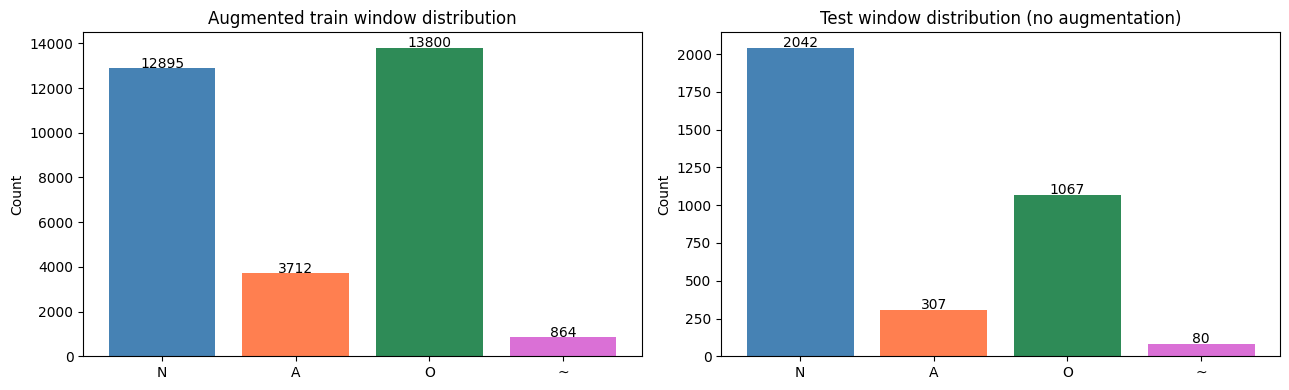


Phase 1 complete. Files in ../../dataset/input/ECG_Hierarchical/:
  X_test_feat.npy                               0.55 MB
  X_test_sig.npy                               62.93 MB
  X_test_spec.dat                             875.47 MB
  X_train_feat.npy                              4.88 MB
  X_train_sig.npy                             562.88 MB
  X_train_spec.dat                          11064.41 MB
  class_distribution.png                        0.03 MB
  feat_cols.pkl                                 0.00 MB
  memmap_shapes.pkl                             0.00 MB
  nonnormal_mask.npy                            0.03 MB
  sample_spectrograms.png                       1.26 MB
  scaler.pkl                                    0.00 MB
  test_rids_spec.npy                            0.04 MB
  train_rids_spec.npy                           0.44 MB
  y_test.npy                                    0.03 MB
  y_test_3class_spec.npy                        0.01 MB
  y_train_3class.npy                 

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_names = ["N", "A", "O", "~"]

train_counts = [np.sum(data["y_train_4class"] == i) for i in range(4)]
test_counts  = [np.sum(data["y_test"] == i)         for i in range(4)]
colors = ["steelblue", "coral", "seagreen", "orchid"]

axes[0].bar(label_names, train_counts, color=colors)
axes[0].set_title("Augmented train window distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(train_counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

axes[1].bar(label_names, test_counts, color=colors)
axes[1].set_title("Test window distribution (no augmentation)")
axes[1].set_ylabel("Count")
for i, v in enumerate(test_counts):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../../dataset/input/ECG_Hierarchical/class_distribution.png", dpi=100)
plt.show()

print("\nPhase 1 complete. Files in ../../dataset/input/ECG_Hierarchical/:")
for fname in sorted(os.listdir("../../dataset/input/ECG_Hierarchical")):
    fpath = os.path.join("../../dataset/input/ECG_Hierarchical", fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f"  {fname:40s}  {size:8.2f} MB")